In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
import wandb
from wandb.integration.sb3 import WandbCallback

from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.evaluation import evaluate_policy

from rl4mm.gym.HistoricalOrderbookEnvironment import HistoricalOrderbookEnvironment
from rl4mm.agents.baseline_agents import RandomAgent, Teradactyl, FixedActionAgent
from rl4mm.features.Features import Portfolio

warnings.filterwarnings('ignore')

/home/anton/rl4mm/rl4mm/gym/HistoricalOrderbookEnvironment.py:49: FutureWarning: 'S' is deprecated and will be removed in a future version. Please use 's' instead of 'S'.
  ORDERBOOK_MIN_STEP = pd.to_timedelta(ORDERBOOK_FREQ)


In [4]:
from datetime import datetime, timedelta, time
from rl4mm.database.HistoricalDatabase import HistoricalDatabase
from sqlalchemy import func
from rl4mm.database.models import Book
import math

db      = HistoricalDatabase()
session = db.session_maker()
first_ts = session.query(func.min(Book.timestamp)).filter(
               Book.exchange=="NASDAQ", Book.ticker=="MSFT").scalar()
last_ts  = session.query(func.max(Book.timestamp)).filter(
               Book.exchange=="NASDAQ", Book.ticker=="MSFT").scalar()
session.close()
print(first_ts)
print(last_ts)

2012-06-21 09:30:00.995225
2012-06-21 09:30:08.026294


In [5]:
step_size_sec = 1
warm_up_sec = 1
window_size   = timedelta(seconds=step_size_sec)     # 0.1 s look-back
shift         = timedelta(seconds=2)                 # <- 2 s, not 0.1 s

####################################3

day_start = lambda ts: datetime.combine(ts.date(), time())   # midnight of that day
min_start_timedelta = (first_ts - day_start(first_ts)) + shift
max_end_timedelta   = last_ts  - day_start(last_ts)

allowed_length      = max_end_timedelta - min_start_timedelta
episode_length_sec  = math.floor(allowed_length.total_seconds())
episode_length_sec  = int(episode_length_sec // step_size_sec) * step_size_sec

print(min_start_timedelta)
print(max_end_timedelta)
print(episode_length_sec)

9:30:02.995225
9:30:08.026294
5


In [8]:
from rl4mm.simulation.OrderbookSimulator import OrderbookSimulator
from rl4mm.features.Features import Spread, PriceMove, Inventory
from datetime import timedelta

def create_environment(seed=42):
    """Create a configured HistoricalOrderbookEnvironment"""

    features = [
        Spread(update_frequency=timedelta(seconds=step_size_sec)),
        PriceMove(name=f"price_move_{step_size_sec}_sec",
                  update_frequency=timedelta(seconds=step_size_sec),
                  lookback_periods=1),
        Inventory(update_frequency=timedelta(seconds=step_size_sec)),
    ]

    env = HistoricalOrderbookEnvironment(
        features=features,
        ticker="MSFT",
        step_size=timedelta(seconds=step_size_sec),
        episode_length=timedelta(seconds=episode_length_sec),
        initial_portfolio=Portfolio(inventory=0, cash=10000),
        max_inventory=1000,
        min_date=first_ts.date(),
        max_date=last_ts.date(),
        min_start_timedelta=min_start_timedelta,
        max_end_timedelta=max_end_timedelta,
        market_order_clearing=False,
        warm_up=timedelta(seconds=warm_up_sec),
    )
    env.seed(seed)

    return env

# Create environment for testing
test_env = create_environment()
# print(f"Action space: {test_env.action_space}")
# print(f"Observation space: {test_env.observation_space}")
# print(f"Action space shape: {test_env.action_space.shape}")
# print(f"Observation space shape: {test_env.observation_space.shape}")

obs = test_env.reset()
print(obs)

[ 300.         -119.07736174    0.        ]


## Baseline Agents Setup & evaluation

Initialize baseline agents for comparison.


In [9]:
def evaluate_agent(agent, env, n_episodes=20, agent_type="baseline"):
    """Evaluate an agent and return performance metrics"""
    rewards = []
    episode_lengths = []
    final_inventories = []
    final_cash = []
    final_portfolio_values = []
    pnl_trajectories = []
    
    for episode in range(n_episodes):
        obs = env.reset()
        total_reward = 0
        steps = 0
        done = False
        pnl_trajectory = [0]  # Start with 0 PnL
        initial_portfolio_value = env.mark_to_market_value()
        
        while not done:
            if agent_type == "ppo":
                action, _ = agent.predict(obs, deterministic=False)
            else:
                action = agent.get_action(obs)
            
            obs, reward, done, info = env.step(action)
            total_reward += reward
            steps += 1
            
            # Track PnL relative to initial portfolio value
            current_pnl = env.mark_to_market_value() - initial_portfolio_value
            pnl_trajectory.append(current_pnl)
        
        rewards.append(total_reward)
        episode_lengths.append(steps)
        final_inventories.append(env.state.portfolio.inventory)
        final_cash.append(env.state.portfolio.cash)
        final_portfolio_values.append(env.mark_to_market_value())
        pnl_trajectories.append(pnl_trajectory)
    
    return {
        'rewards': rewards,
        'episode_lengths': episode_lengths,
        'final_inventories': final_inventories,
        'final_cash': final_cash,
        'final_portfolio_values': final_portfolio_values,
        'pnl_trajectories': pnl_trajectories,
        'mean_reward': np.mean(rewards),
        'std_reward': np.std(rewards),
        'mean_episode_length': np.mean(episode_lengths),
        'mean_final_inventory': np.mean(final_inventories),
        'mean_final_portfolio_value': np.mean(final_portfolio_values)
    }


In [10]:
# Initialize baseline agents
random_agent = RandomAgent(test_env, seed=42)
teradactyl_agent = Teradactyl(max_inventory=1000, default_kappa=5.0, default_omega=0.3, inventory_index=2)
fixed_action_agent = FixedActionAgent(np.array([2.0, 1.5, 2.0, 1.5, 500.0]))

baseline_agents = {
    "Random": random_agent,
    "Teradactyl": teradactyl_agent,
    "Fixed Action": fixed_action_agent
}

print("Baseline agents initialized:")
for name, agent in baseline_agents.items():
    print(f"- {name}")


Baseline agents initialized:
- Random
- Teradactyl
- Fixed Action


In [11]:
# Set up evaluation parameters
n_eval_episodes = 20
results = {}

def evaluate_agent(agent, seed=42, n_episodes=20, agent_type="baseline"):
    """Evaluate an agent over multiple episodes with reproducible environment seeds.
    
    Args:
        agent: The agent to evaluate
        seed (int): Master seed for generating episode seeds
        n_episodes (int): Number of episodes to evaluate
        agent_type (str): Type of agent ("baseline" or "ppo")
    """
    # Generate episode seeds deterministically from the master seed
    rng = np.random.RandomState(seed)
    episode_seeds = rng.randint(0, 2**31, size=n_episodes)
    print(f"Generated {n_episodes} episode seeds from master seed {seed}")
    print(f"Episode seeds: {episode_seeds[:5]}...")  # Show first 5 seeds
    
    rewards = []
    episode_lengths = []
    final_inventories = []
    final_cash = []
    final_portfolio_values = []
    pnl_trajectories = []
    
    for episode_idx, episode_seed in enumerate(episode_seeds):
        # Create fresh environment with specific seed for this episode
        env = create_environment(seed=int(episode_seed))
        
        obs = env.reset()
        total_reward = 0
        steps = 0
        done = False
        pnl_trajectory = [0]  # Start with 0 PnL
        initial_portfolio_value = env.mark_to_market_value()
        
        while not done:
            if agent_type == "ppo":
                action, _ = agent.predict(obs, deterministic=False)
            else:
                action = agent.get_action(obs)
            
            obs, reward, done, info = env.step(action)
            total_reward += reward
            steps += 1
            
            # Track PnL relative to initial portfolio value
            current_pnl = env.mark_to_market_value() - initial_portfolio_value
            pnl_trajectory.append(current_pnl)
        
        rewards.append(total_reward)
        episode_lengths.append(steps)
        final_inventories.append(env.state.portfolio.inventory)
        final_cash.append(env.state.portfolio.cash)
        final_portfolio_values.append(env.mark_to_market_value())
        pnl_trajectories.append(pnl_trajectory)
    
    return {
        'rewards': rewards,
        'episode_lengths': episode_lengths,
        'final_inventories': final_inventories,
        'final_cash': final_cash,
        'final_portfolio_values': final_portfolio_values,
        'pnl_trajectories': pnl_trajectories,
        'mean_reward': np.mean(rewards),
        'std_reward': np.std(rewards),
        'mean_episode_length': np.mean(episode_lengths),
        'mean_final_inventory': np.mean(final_inventories),
        'mean_final_portfolio_value': np.mean(final_portfolio_values)
    }

print("Evaluating baseline agents...")

# Evaluate baseline agents
master_seed = 42  # Use same master seed for all agents
for name, agent in baseline_agents.items():
    if name not in results.keys():
        print(f"Evaluating {name} agent...")
        results[name] = evaluate_agent(agent, seed=master_seed, n_episodes=n_eval_episodes, agent_type="baseline")
    else:
        print(f"{name} agent already evaluated")

Evaluating baseline agents...
Evaluating Random agent...
Generated 20 episode seeds from master seed 42
Episode seeds: [1608637542 1273642419 1935803228  787846414  996406378]...
Evaluating Teradactyl agent...
Generated 20 episode seeds from master seed 42
Episode seeds: [1608637542 1273642419 1935803228  787846414  996406378]...
Evaluating Fixed Action agent...
Generated 20 episode seeds from master seed 42
Episode seeds: [1608637542 1273642419 1935803228  787846414  996406378]...


## PPO Agent Training

Train a PPO agent on the environment.


In [12]:
# Compute training parameters based on environment step size and duration
steps_per_episode = int(episode_length_sec / step_size_sec)
print(f"Steps per episode: {steps_per_episode}")

Steps per episode: 5


In [13]:
# Training parameter computation based on environment configuration
N_FULL_EPISODES = 10  # Global constant for number of passes through the data

total_timesteps = N_FULL_EPISODES * steps_per_episode

# Set n_steps to be a fraction of episode length that fits well with batch_size
# Use smaller of: steps_per_episode or a multiple of batch_size that's <= steps_per_episode
# batch_size = 64
# n_steps = 512

batch_size = 100
n_steps = 100

print(f"Environment configuration:")
print(f"  Step size: {step_size_sec} seconds")
print(f"  Episode length: {episode_length_sec} seconds")
print(f"  Steps per episode: {steps_per_episode}")
print(f"Training configuration:")
print(f"  Number of passes: {N_FULL_EPISODES}")
print(f"  Total timesteps: {total_timesteps}")
print(f"  n_steps (rollout length): {n_steps}")
print(f"  Batch size: {batch_size}")

config = dict(
    agent={
        "learning_rate": 3e-4,
        "n_steps": n_steps,
        "batch_size": batch_size,
        "n_epochs": 10,
        "gamma": 0.99,
        "gae_lambda": 0.95,
        "clip_range": 0.2,
        "ent_coef": 0.01,
    },
    env={
        "total_timesteps": total_timesteps,
        "episode_length_sec": episode_length_sec,
        "ticker": "MSFT"
    }
)

Environment configuration:
  Step size: 1 seconds
  Episode length: 5 seconds
  Steps per episode: 5
Training configuration:
  Number of passes: 10
  Total timesteps: 50
  n_steps (rollout length): 100
  Batch size: 100


In [14]:
# Create vectorized environment for PPO training

def make_env():
    env = create_environment()
    return env

vec_env = make_vec_env(make_env, n_envs=1)


In [15]:
# Initialize wandb
run = wandb.init(
    project="rl4mm-ppo-comparison",
    config=config,
    sync_tensorboard=True  # Enable tensorboard logging sync
)

# Initialize PPO agent with tensorboard logging
ppo_agent = PPO(
    "MlpPolicy",
    vec_env,
    verbose=1,
    tensorboard_log=f"runs/{run.id}",  # Enable tensorboard logging
    **config["agent"]
)

# Use the built-in WandbCallback
ppo_agent.learn(
    total_timesteps=config["env"]["total_timesteps"],
    progress_bar=True,
    callback=WandbCallback(
        gradient_save_freq=100,
        verbose=0,
    )
)

wandb: Currently logged in as: tony-pitchblack (overfit1010) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Using cpu device
Logging to runs/1mw5b4al/PPO_1


Output()

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 5        |
|    ep_rew_mean     | 1.1e+04  |
| time/              |          |
|    fps             | 12       |
|    iterations      | 1        |
|    time_elapsed    | 8        |
|    total_timesteps | 100      |
---------------------------------


In [16]:
# Evaluate PPO agent using the same master seed as baseline agents
print("Evaluating PPO agent...")
results["PPO"] = evaluate_agent(ppo_agent, seed=master_seed, n_episodes=n_eval_episodes, agent_type="ppo")

Evaluating PPO agent...
Generated 20 episode seeds from master seed 42
Episode seeds: [1608637542 1273642419 1935803228  787846414  996406378]...


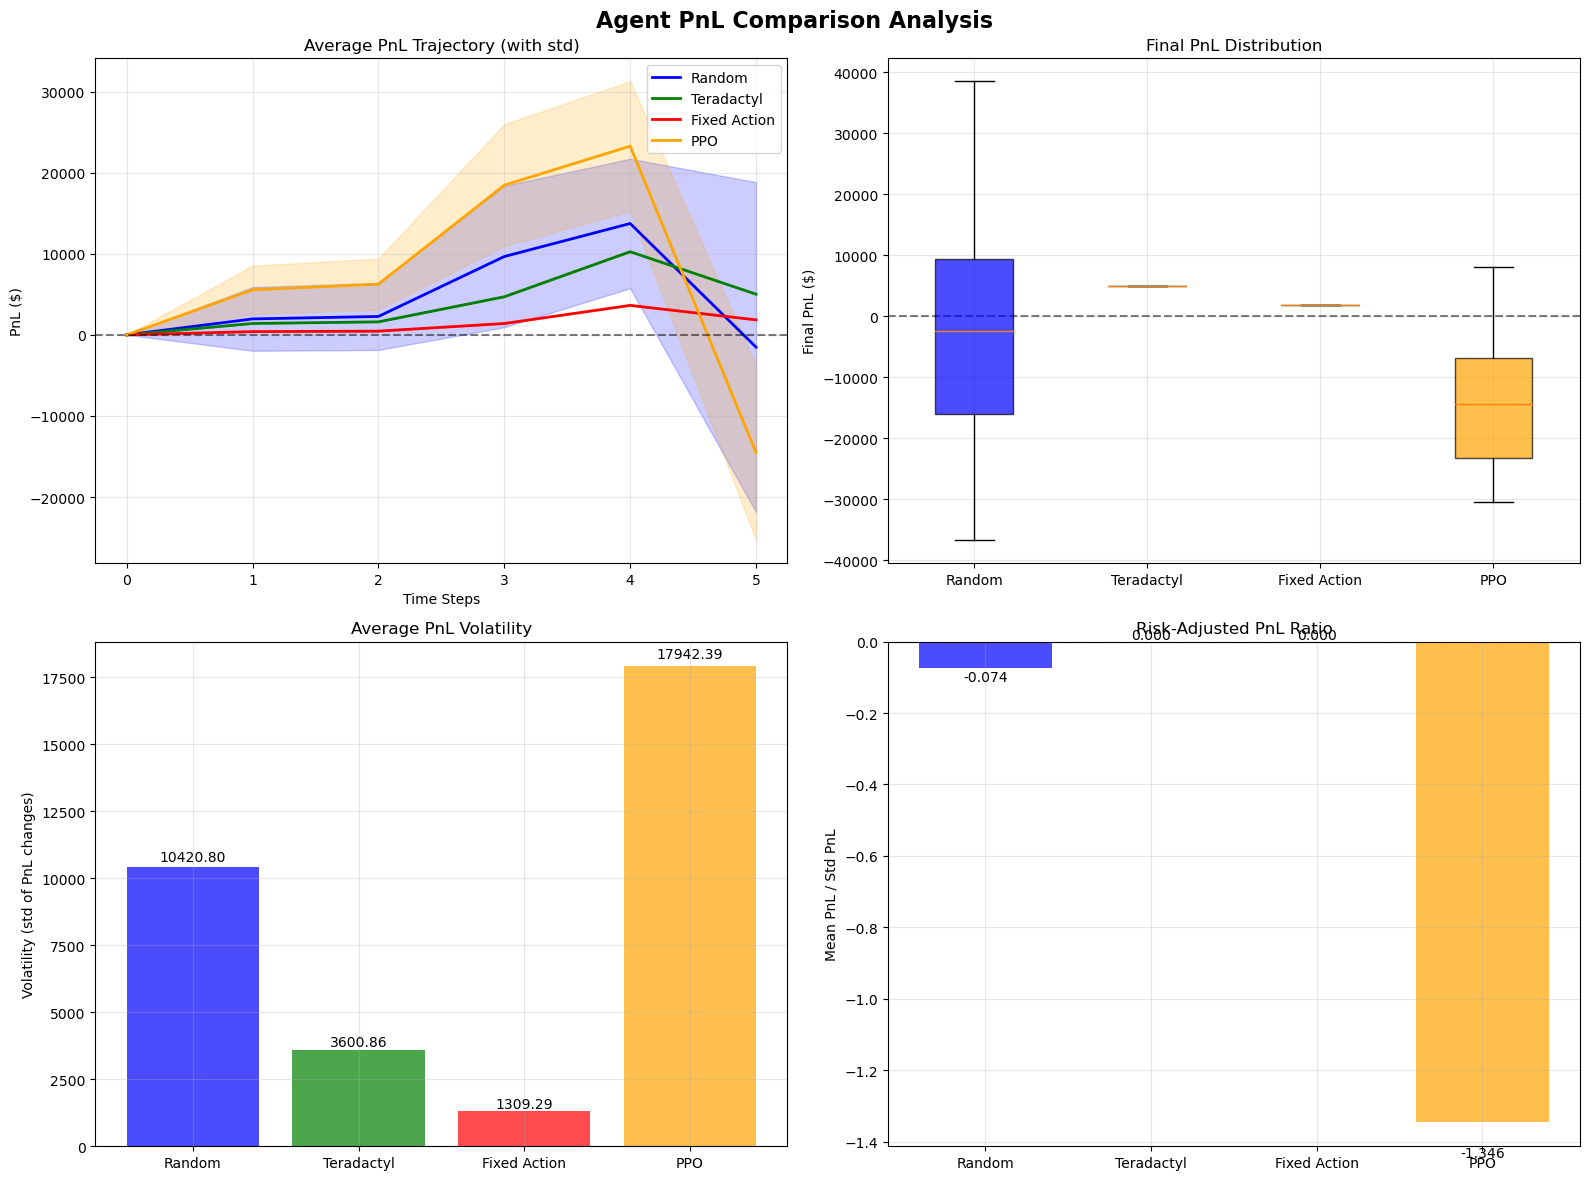

In [17]:
# PnL Trajectory Comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Agent PnL Comparison Analysis', fontsize=16, fontweight='bold')

colors = ['blue', 'green', 'red', 'orange']
agent_names = list(results.keys())

# 1. Average PnL Trajectory
ax1 = axes[0, 0]
for i, agent_name in enumerate(agent_names):
    pnl_trajectories = results[agent_name]['pnl_trajectories']
    # Calculate average PnL across all episodes
    max_length = max(len(traj) for traj in pnl_trajectories)
    padded_trajectories = []
    for traj in pnl_trajectories:
        padded = traj + [traj[-1]] * (max_length - len(traj))
        padded_trajectories.append(padded)
    
    avg_pnl = np.mean(padded_trajectories, axis=0)
    std_pnl = np.std(padded_trajectories, axis=0)
    
    time_steps = range(len(avg_pnl))
    ax1.plot(time_steps, avg_pnl, label=agent_name, color=colors[i], linewidth=2)
    ax1.fill_between(time_steps, avg_pnl - std_pnl, avg_pnl + std_pnl, 
                     color=colors[i], alpha=0.2)

ax1.set_title('Average PnL Trajectory (with std)')
ax1.set_xlabel('Time Steps')
ax1.set_ylabel('PnL ($)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='black', linestyle='--', alpha=0.5)

# 2. Final PnL Distribution
ax2 = axes[0, 1]
final_pnls = []
for agent_name in agent_names:
    agent_final_pnls = [traj[-1] for traj in results[agent_name]['pnl_trajectories']]
    final_pnls.append(agent_final_pnls)

bp = ax2.boxplot(final_pnls, labels=agent_names, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax2.set_title('Final PnL Distribution')
ax2.set_ylabel('Final PnL ($)')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)

# 3. PnL Volatility (Risk) Comparison
ax3 = axes[1, 0]
volatilities = []
for agent_name in agent_names:
    pnl_trajectories = results[agent_name]['pnl_trajectories']
    agent_volatilities = []
    for traj in pnl_trajectories:
        if len(traj) > 1:
            pnl_changes = np.diff(traj)
            volatility = np.std(pnl_changes)
            agent_volatilities.append(volatility)
    volatilities.append(np.mean(agent_volatilities) if agent_volatilities else 0)

bars = ax3.bar(agent_names, volatilities, color=colors, alpha=0.7)
ax3.set_title('Average PnL Volatility')
ax3.set_ylabel('Volatility (std of PnL changes)')
ax3.grid(True, alpha=0.3)

# Add value labels on bars
for bar, value in zip(bars, volatilities):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
            f'{value:.2f}', ha='center', va='bottom')

# 4. Risk-Adjusted PnL (Sharpe-like ratio for PnL)
ax4 = axes[1, 1]
risk_adjusted_ratios = []
for i, agent_name in enumerate(agent_names):
    final_pnl_values = [traj[-1] for traj in results[agent_name]['pnl_trajectories']]
    mean_final_pnl = np.mean(final_pnl_values)
    std_final_pnl = np.std(final_pnl_values)
    ratio = mean_final_pnl / std_final_pnl if std_final_pnl > 0 else 0
    risk_adjusted_ratios.append(ratio)

bars = ax4.bar(agent_names, risk_adjusted_ratios, color=colors, alpha=0.7)
ax4.set_title('Risk-Adjusted PnL Ratio')
ax4.set_ylabel('Mean PnL / Std PnL')
ax4.grid(True, alpha=0.3)
ax4.axhline(y=0, color='black', linestyle='--', alpha=0.5)

# Add value labels on bars
for bar, value in zip(bars, risk_adjusted_ratios):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + np.sign(height)*abs(height)*0.05,
            f'{value:.3f}', ha='center', va='bottom' if height >= 0 else 'top')

plt.tight_layout()
plt.show()

# Log final metrics to wandb
if 'wandb' in globals():
    final_metrics = {}
    for agent_name in agent_names:
        final_pnl_values = [traj[-1] for traj in results[agent_name]['pnl_trajectories']]
        final_metrics[f'{agent_name}_mean_final_pnl'] = np.mean(final_pnl_values)
        final_metrics[f'{agent_name}_std_final_pnl'] = np.std(final_pnl_values)
        final_metrics[f'{agent_name}_mean_reward'] = results[agent_name]['mean_reward']
        final_metrics[f'{agent_name}_volatility'] = volatilities[agent_names.index(agent_name)]
        final_metrics[f'{agent_name}_risk_adjusted_pnl'] = risk_adjusted_ratios[agent_names.index(agent_name)]
    
    wandb.log(final_metrics)


In [18]:
# Create summary table
summary_data = []
for agent_name, result in results.items():
    summary_data.append({
        'Agent': agent_name,
        'Mean Reward': result['mean_reward'],
        'Std Reward': result['std_reward'],
        'Mean Episode Length': result['mean_episode_length'],
        'Mean Final Inventory': result['mean_final_inventory'],
        'Mean Portfolio Value': result['mean_final_portfolio_value']
    })

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.round(4)
print("\nPerformance Summary:")
print(summary_df.to_string(index=False))



Performance Summary:
       Agent  Mean Reward  Std Reward  Mean Episode Length  Mean Final Inventory  Mean Portfolio Value
      Random    1339.4261  17962.6122                  5.0                 66.85             8485.1349
  Teradactyl    7280.2428      0.0000                  5.0                 53.00            15014.4578
Fixed Action    3041.8657      0.0000                  5.0                 28.00            11846.7066
         PPO  -10031.4185   9310.1536                  5.0                104.30            -4516.2172
